In [1]:
!pip install scikit-learn seaborn pymfe -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: Obter conjunto de datasets de treinamento

In [3]:
#Carregando os datasets
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3', 
         'qsar', 'solar-flare']

#errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {} 
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name blood-transfusion-service-center exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1464
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46913

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml

Fetching dataset: diabetes
Fetching dataset: blood-transfusion-service-center
Fetching dataset: monks-problems-2
Fetching dataset: tic-tac-toe
Fetching dataset: titanic
Fetching dataset: pc1
Fetching dataset: kr-vs-kp
Fetching dataset: phoneme
Fetching dataset: wdbc
Fetching dataset: semeion
Fetching dataset: isolet


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name semeion exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1501
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41973

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Mu

Fetching dataset: cnae-9
Fetching dataset: ilpd-numeric
Fetching dataset: students_scores
Fetching dataset: usps


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name cnae-9 exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1468
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41967

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ilpd-numeric exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=41943
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41945

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarnin

Fetching dataset: ibm-employee-performance
Fetching dataset: mushroom
Fetching dataset: segment
Fetching dataset: autoUniv-au1-1000
Fetching dataset: pizzacutter3
Fetching dataset: qsar
Fetching dataset: solar-flare
Finished fetching 22 datasets.


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ibm-employee-performance exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43895
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43897

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name mushroom exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=24
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=43922

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328

## Passo 1.1: Obter conjunto de datasets complementares

In [4]:
# Carregando datasets complementares
complementary_names = [
    'adult', 'credit-g', 'bank-marketing', 
    'madelon', 'spambase', 'yeast', 
    'ionosphere', 'steel-plates-fault', 'gas-drift',
    'nursery', 'car', 'heart-statlog'
]

complementary_datasets = {} 
for name in complementary_names:
    print('Fetching complementary dataset: {}'.format(name))
    try:
        complementary_datasets[name] = fetch_openml(name=name, as_frame=True)
    except Exception as e:
        print(f'Error fetching {name}: {e}')

print(f'Finished fetching {len(complementary_datasets)} complementary datasets.')

Fetching complementary dataset: adult
Fetching complementary dataset: credit-g
Fetching complementary dataset: bank-marketing


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multipl

Fetching complementary dataset: madelon
Fetching complementary dataset: spambase
Fetching complementary dataset: yeast
Fetching complementary dataset: ionosphere
Fetching complementary dataset: steel-plates-fault
Fetching complementary dataset: gas-drift


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name yeast exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=181
- version 4, status: active
  url: https://www.openml.org/search?type=data&id=40597

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name steel-plates-fault exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1504
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40982

  warn(warning_msg)


Fetching complementary dataset: nursery
Fetching complementary dataset: car
Fetching complementary dataset: heart-statlog
Finished fetching 12 complementary datasets.


c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


## Passo 1.2: Combinar todos os datasets

In [5]:
# Combinar datasets originais e complementares
all_datasets = {**datasets, **complementary_datasets}
all_names = names + list(complementary_datasets.keys())

print(f'Total datasets: {len(all_datasets)}')
print(f'Original datasets: {len(datasets)}')
print(f'Complementary datasets: {len(complementary_datasets)}')

Total datasets: 34
Original datasets: 22
Complementary datasets: 12


## Passo 2: Avaliar performance dos classificadores nos datasets

In [6]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through ALL datasets (original + complementary)
for dataset_name in all_names:
    print(f'Processing dataset: {dataset_name}')
    
    # Determine dataset group for comparison
    dataset_group = 'Original' if dataset_name in names else 'Complementary'
    
    # Get data and target
    X = all_datasets[dataset_name]['data']
    y = all_datasets[dataset_name]['target']
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    
    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')
        
        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy', 
                                    return_train_score=False)
        
        # Extract fold accuracies
        fold_accs = cv_results['test_score']
        
        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Group': dataset_group,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }
        
        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: diabetes
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: blood-transfusion-service-center
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: monks-problems-2
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users

Done
Processing dataset: tic-tac-toe
Falling back to simple imputation strategy.
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users

Done
Processing dataset: titanic
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: pc1
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

...

Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Done
Processing dataset: car
Falling back to simple imputation strategy.
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: heart-statlog
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done


In [7]:
performances_df

,Dataset,Group,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,Original,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.017735,0.009605
1,diabetes,Original,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.034856,0.021131
2,diabetes,Original,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.009182,0.040558
3,diabetes,Original,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.137847,0.007090
4,diabetes,Original,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.010798,0.007873
...,...,...,...,...,...,...,...,...,...,...,...,...
199,heart-statlog,Complementary,SVM,0.740741,0.703704,0.500000,0.592593,0.759259,0.659259,0.098410,0.014004,0.009510
200,heart-statlog,Complementary,KNN,0.648148,0.629630,0.518519,0.629630,0.759259,0.637037,0.076444,0.009006,0.022021
201,heart-statlog,Complementary,LogisticRegression,0.870370,0.907407,0.777778,0.777778,0.870370,0.840741,0.053158,0.826028,0.008684
202,heart-statlog,Complementary,Perceptron,0.444444,0.592593,0.462963,0.444444,0.722222,0.533333,0.109494,0.006502,0.008309


## Passo 3: Extrair meta-features dos datasets

In [8]:
# Extract meta-features from ALL datasets (original + complementary)
meta_features = []

for dataset_name in all_names:  
    print(f'Extracting meta-features from {dataset_name}...', end=' ')
    
    # Get data and target
    X = all_datasets[dataset_name]['data']
    y = all_datasets[dataset_name]['target']
    
    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)
    
    # Extract meta-features
    try:
        mfe = MFE(groups=["general", "statistical", "info-theory", 
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()
        
        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}
        
        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from diabetes... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


Done
Extracting meta-features from blood-transfusion-service-center... Done
Extracting meta-features from monks-problems-2... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\statistical.py:1266: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\statistical.py:1266: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices
c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\statistical.py:1271: RuntimeWarning: invalid value encountered in log
  * np.log(np.linalg.det(pooled_cov_mat))


Done
Extracting meta-features from tic-tac-toe... 

...

Done
Extracting meta-features from car... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\statistical.py:1266: RuntimeWarning: divide by zero encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices


Done
Extracting meta-features from heart-statlog... 

c:\Users\JAOF-PC\anaconda3\envs\seg_env\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


Done


In [9]:
meta_features_df

,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,cov.mean,...,sd.mean,sd_ratio,sil,skewness.mean,sparsity.mean,t_mean.mean,var.mean,vdb,vdu,w_lambda
diabetes,2.884044e-02,2.958106,0.010417,0.550684,0.000000,24.299108,0.012490,0.933134,0.171657,1.093502e+02,...,25.733743,1.032594,0.104260,0.527181,1.592296e-02,40.209208,1.893059e+03,4.427474,3.677824e-08,6.967469e-01
blood-transfusion-service-center,2.220620e-01,2.882541,0.005348,0.359244,0.000000,37.439438,0.010159,0.791645,0.465998,5.568267e+03,...,374.534549,NaN,0.178546,2.254043,2.511784e-02,267.449444,5.329470e+05,2.841441,0.000000e+00,8.709436e-01
monks-problems-2,4.895971e-04,1.458931,0.009983,0.139975,0.000000,1.992991,0.002467,0.927437,0.013879,8.194676e-03,...,0.759888,NaN,-0.001832,-0.003244,3.739583e-01,1.915974,6.221104e-01,16.096022,2.562547e-06,9.804071e-01
tic-tac-toe,1.467639e-02,1.538037,0.009395,0.966025,NaN,19.371543,0.015851,0.930954,0.125923,2.937108e-02,...,0.481048,NaN,0.023668,0.524541,3.326367e-01,0.294042,2.317603e-01,6.684681,2.083475e-06,6.679638e-02
titanic,5.480887e-02,0.958873,0.001363,0.470040,0.000000,236.113508,0.080603,0.907651,0.185447,1.856629e-01,...,1.000460,NaN,0.234431,0.683594,4.164015e-01,0.151765,1.000920e+00,2.585854,0.000000e+00,7.790622e-01
pc1,2.108640e-01,2.937619,0.018936,0.386223,0.000000,15.547851,0.006607,0.363800,0.632733,9.113908e+06,...,8678.609589,NaN,0.620808,7.986854,1.263712e-02,266.343759,1.391022e+09,2.173658,0.000000e+00,8.508315e-01
kr-vs-kp,2.094672e-02,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,1.123369e-02,...,0.332009,NaN,0.031625,4.108820,4.952124e-01,0.224809,1.303675e-01,5.676987,8.009382e-08,3.602836e-01
phoneme,5.784617e-02,4.025713,0.000925,0.497794,0.000000,408.510486,0.010767,0.873182,0.126089,1.260889e-01,...,1.000000,1.234492,0.087266,0.779033,9.700102e-06,-0.151914,1.000000e+00,3.102294,5.578544e-10,7.522012e-01
wdbc,6.478506e-02,2.999956,0.052724,0.879957,0.000000,633.631104,0.051585,0.952635,0.394897,6.764651e+02,...,34.904719,NaN,0.513697,1.731241,2.087540e-04,53.294606,1.506322e+04,0.720645,3.317102e-08,2.256753e-01
semeion,2.294132e-02,0.875007,0.160703,0.788536,0.000000,41.251899,0.188329,3.321819,0.096662,2.013985e-02,...,0.455351,NaN,0.049640,0.807858,4.996859e-01,0.222550,2.092574e-01,3.661805,1.756471e-05,3.074668e-05


# Passo 4: Combinar as meta-features e as performances

In [10]:
performances_df

,Dataset,Group,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,Original,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.017735,0.009605
1,diabetes,Original,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.034856,0.021131
2,diabetes,Original,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.009182,0.040558
3,diabetes,Original,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.137847,0.007090
4,diabetes,Original,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.010798,0.007873
...,...,...,...,...,...,...,...,...,...,...,...,...
199,heart-statlog,Complementary,SVM,0.740741,0.703704,0.500000,0.592593,0.759259,0.659259,0.098410,0.014004,0.009510
200,heart-statlog,Complementary,KNN,0.648148,0.629630,0.518519,0.629630,0.759259,0.637037,0.076444,0.009006,0.022021
201,heart-statlog,Complementary,LogisticRegression,0.870370,0.907407,0.777778,0.777778,0.870370,0.840741,0.053158,0.826028,0.008684
202,heart-statlog,Complementary,Perceptron,0.444444,0.592593,0.462963,0.444444,0.722222,0.533333,0.109494,0.006502,0.008309


In [11]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,adult,0.799783,0.732157,0.805331,0.782686,0.655989,0.760718
1,autoUniv-au1-1000,0.649000,0.734000,0.735000,0.703000,0.697000,0.758000
2,bank-marketing,0.836235,0.876778,0.883546,0.711438,0.746975,0.883015
3,blood-transfusion-service-center,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
4,car,0.991897,0.929408,0.718159,0.987273,0.669006,0.964708
5,cnae-9,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
6,credit-g,0.679000,0.625000,0.682000,0.692000,0.543000,0.700000
7,diabetes,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
8,gas-drift,0.972178,0.981955,0.974623,0.955572,0.896621,0.887994
9,heart-statlog,0.725926,0.637037,0.840741,0.792593,0.533333,0.659259


In [12]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df, 
    left_on='Dataset', 
    right_index=True, 
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [13]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,var.mean,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,adult,4.297678e-02,1.932533,0.000287,0.640859,6.000000,1.962530,0.028252,0.793844,0.019860,...,1.013837e+08,98.138149,0.000000e+00,5.893002e-01,0.799783,0.732157,0.805331,0.782686,0.655989,0.760718
1,autoUniv-au1-1000,6.335705e-03,0.959212,0.020000,0.309874,0.000000,4.879801,0.005145,0.825234,0.039626,...,2.366491e-01,12.510967,1.195378e-06,9.039781e-01,0.649000,0.734000,0.735000,0.703000,0.697000,0.758000
2,bank-marketing,2.005550e-02,2.322286,0.000354,0.549815,1.285714,176.319001,0.007378,0.520631,0.051938,...,2.173755e+05,5.807756,9.614565e-14,6.977032e-01,0.836235,0.876778,0.883546,0.711438,0.746975,0.883015
3,blood-transfusion-service-center,2.220620e-01,2.882541,0.005348,0.359244,0.000000,37.439438,0.010159,0.791645,0.465998,...,5.329470e+05,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
4,car,-4.966668e-08,1.792481,0.003472,0.739635,NaN,54.977986,0.043189,0.881008,0.045833,...,2.006369e-01,5.100379,4.605685e-07,4.529404e-01,0.991897,0.929408,0.718159,0.987273,0.669006,0.964708
5,cnae-9,1.486115e-04,0.050160,0.792593,0.975141,0.000000,28.121009,0.034934,3.169925,0.009671,...,8.251032e-03,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
6,credit-g,1.489016e-02,1.653984,0.020000,0.530518,1.857143,24.482511,0.008087,0.881291,0.060362,...,1.626148e+05,4.661395,1.025108e-09,7.185509e-01,0.679000,0.625000,0.682000,0.692000,0.543000,0.700000
7,diabetes,2.884044e-02,2.958106,0.010417,0.550684,0.000000,24.299108,0.012490,0.933134,0.171657,...,1.893059e+03,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
8,gas-drift,7.684189e-02,4.584962,0.009202,0.871862,0.000000,2229.175178,0.026648,2.545696,0.490339,...,1.194190e+08,2.841609,1.594200e-11,2.611931e-04,0.972178,0.981955,0.974623,0.955572,0.896621,0.887994
9,heart-statlog,3.245292e-02,1.646719,0.048148,0.738409,0.000000,11.137445,0.082746,0.991076,0.157526,...,2.783801e+02,4.156427,7.394145e-07,4.547522e-01,0.725926,0.637037,0.840741,0.792593,0.533333,0.659259


In [14]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [50]:
# Add Group column to identify original vs complementary datasets
meta_dataset['Group'] = meta_dataset['Dataset'].apply(
    lambda x: 'Original' if x in names else 'Complementary'
)

# Save meta_dataset to CSV for future use
meta_dataset.to_csv('meta_dataset.csv', index=False)
print(f'meta_dataset saved to meta_dataset.csv with {len(meta_dataset)} rows')

meta_dataset saved to meta_dataset.csv with 34 rows


In [15]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,adult,4.297678e-02,1.932533,0.000287,0.640859,6.000000,1.962530,0.028252,0.793844,0.019860,...,98.138149,0.000000e+00,5.893002e-01,0.799783,0.732157,0.805331,0.782686,0.655989,0.760718,LogisticRegression
1,autoUniv-au1-1000,6.335705e-03,0.959212,0.020000,0.309874,0.000000,4.879801,0.005145,0.825234,0.039626,...,12.510967,1.195378e-06,9.039781e-01,0.649000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM
2,bank-marketing,2.005550e-02,2.322286,0.000354,0.549815,1.285714,176.319001,0.007378,0.520631,0.051938,...,5.807756,9.614565e-14,6.977032e-01,0.836235,0.876778,0.883546,0.711438,0.746975,0.883015,LogisticRegression
3,blood-transfusion-service-center,2.220620e-01,2.882541,0.005348,0.359244,0.000000,37.439438,0.010159,0.791645,0.465998,...,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression
4,car,-4.966668e-08,1.792481,0.003472,0.739635,NaN,54.977986,0.043189,0.881008,0.045833,...,5.100379,4.605685e-07,4.529404e-01,0.991897,0.929408,0.718159,0.987273,0.669006,0.964708,DecisionTree
5,cnae-9,1.486115e-04,0.050160,0.792593,0.975141,0.000000,28.121009,0.034934,3.169925,0.009671,...,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP
6,credit-g,1.489016e-02,1.653984,0.020000,0.530518,1.857143,24.482511,0.008087,0.881291,0.060362,...,4.661395,1.025108e-09,7.185509e-01,0.679000,0.625000,0.682000,0.692000,0.543000,0.700000,SVM
7,diabetes,2.884044e-02,2.958106,0.010417,0.550684,0.000000,24.299108,0.012490,0.933134,0.171657,...,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression
8,gas-drift,7.684189e-02,4.584962,0.009202,0.871862,0.000000,2229.175178,0.026648,2.545696,0.490339,...,2.841609,1.594200e-11,2.611931e-04,0.972178,0.981955,0.974623,0.955572,0.896621,0.887994,KNN
9,heart-statlog,3.245292e-02,1.646719,0.048148,0.738409,0.000000,11.137445,0.082746,0.991076,0.157526,...,4.156427,7.394145e-07,4.547522e-01,0.725926,0.637037,0.840741,0.792593,0.533333,0.659259,LogisticRegression


In [16]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
DecisionTree,9
MLP,9
LogisticRegression,8
SVM,6
KNN,2


# Passo 5: Treinar (e avaliar) o meta-modelo

In [17]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    y_pred.append(clf.predict(X_test)[0])
    
    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
summary_df = pd.DataFrame(summary_of_predictions)

# Calculate meta-model accuracy and F1-score
meta_model_accuracy = accuracy_score(y_true, y_pred)
meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')


Meta-model Accuracy: 0.12
Meta-model F1-score: 0.11


In [24]:
# Adicionar informação de grupo ao summary_df
summary_df['Group'] = summary_df['Dataset'].apply(
    lambda x: 'Original' if x in names else 'Complementary'
)

In [25]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred),Group
0,adult,LogisticRegression,0.805331,DecisionTree,0.799783,Complementary
1,autoUniv-au1-1000,SVM,0.758000,MLP,0.703000,Original
2,bank-marketing,LogisticRegression,0.883546,DecisionTree,0.836235,Complementary
3,blood-transfusion-service-center,LogisticRegression,0.772707,DecisionTree,0.709852,Original
4,car,DecisionTree,0.991897,MLP,0.987273,Complementary
5,cnae-9,MLP,0.955556,SVM,0.919444,Original
6,credit-g,SVM,0.700000,LogisticRegression,0.682000,Complementary
7,diabetes,LogisticRegression,0.770792,MLP,0.658925,Original
8,gas-drift,KNN,0.981955,DecisionTree,0.972178,Complementary
9,heart-statlog,LogisticRegression,0.840741,MLP,0.792593,Complementary


In [26]:
# Base-level performance:
summary_df.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,34.000000,34.000000
mean,0.884787,0.837283
std,0.107216,0.134148
min,0.606507,0.505419
25%,0.794247,0.728086
50%,0.925035,0.873567
75%,0.972358,0.950223
max,1.000000,0.998769


In [35]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred),Group,Diff
0,0.799783,0.732157,0.805331,0.782686,0.655989,0.760718,LogisticRegression,0.805331,DecisionTree,0.799783,Complementary,-0.005548
1,0.649000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM,0.758000,MLP,0.703000,Original,-0.055000
2,0.836235,0.876778,0.883546,0.711438,0.746975,0.883015,LogisticRegression,0.883546,DecisionTree,0.836235,Complementary,-0.047312
3,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression,0.772707,DecisionTree,0.709852,Original,-0.062855
4,0.991897,0.929408,0.718159,0.987273,0.669006,0.964708,DecisionTree,0.991897,MLP,0.987273,Complementary,-0.004624
5,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP,0.955556,SVM,0.919444,Original,-0.036111
6,0.679000,0.625000,0.682000,0.692000,0.543000,0.700000,SVM,0.700000,LogisticRegression,0.682000,Complementary,-0.018000
7,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression,0.770792,MLP,0.658925,Original,-0.111867
8,0.972178,0.981955,0.974623,0.955572,0.896621,0.887994,KNN,0.981955,DecisionTree,0.972178,Complementary,-0.009777
9,0.725926,0.637037,0.840741,0.792593,0.533333,0.659259,LogisticRegression,0.840741,MLP,0.792593,Complementary,-0.048148


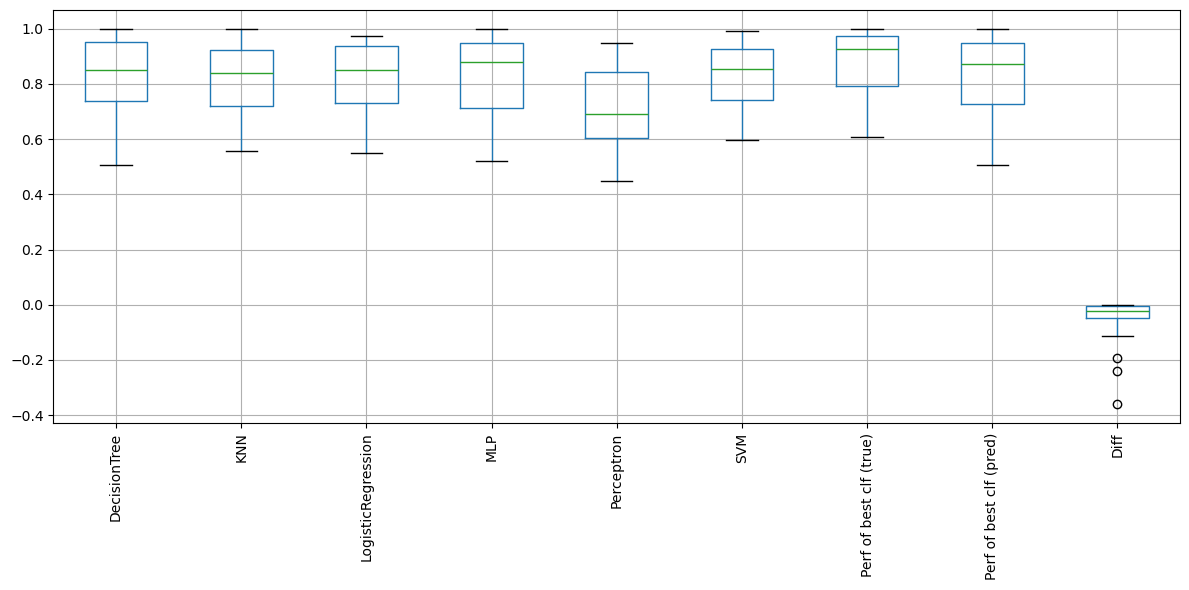

In [39]:
plt.figure(figsize=(12, 6))
final_summary.boxplot(rot=90)
plt.tight_layout()
plt.show()

In [40]:
# Sumário completo do dataset fusionado
print("="*60)
print("SUMÁRIO DO DATASET FUSIONADO")
print("="*60)
print(f"\nTotal de datasets: {len(all_names)}")
print(f"  - Originais: {len(names)}")
print(f"  - Complementares: {len(complementary_names)}")
print(f"\nClassificadores avaliados: {len(classifiers)}")
print(f"Total de experimentos: {len(performances_df)}")
print(f"\n{'='*60}")
print("PERFORMANCE DO META-MODELO (Todos os datasets)")
print("="*60)
print(f"Acurácia: {meta_model_accuracy:.4f}")
print(f"F1-Score: {meta_model_f1:.4f}")
print(f"\nPerformance média (melhor clf verdadeiro): {summary_df['Perf of best clf (true)'].mean():.4f}")
print(f"Performance média (melhor clf predito): {summary_df['Perf of best clf (pred)'].mean():.4f}")
print(f"Diferença: {(summary_df['Perf of best clf (pred)'] - summary_df['Perf of best clf (true)']).mean():.4f}")
print("="*60)

SUMÁRIO DO DATASET FUSIONADO

Total de datasets: 34
  - Originais: 22
  - Complementares: 12

Classificadores avaliados: 6
Total de experimentos: 204

PERFORMANCE DO META-MODELO (Todos os datasets)
Acurácia: 0.1176
F1-Score: 0.1118

Performance média (melhor clf verdadeiro): 0.8848
Performance média (melhor clf predito): 0.8373
Diferença: -0.0475


### Sumário Final: Dataset Fusionado

C:\Users\JAOF-PC\AppData\Local\Temp\ipykernel_8884\1643896386.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  summary_df.boxplot(column=['Perf of best clf (true)', 'Perf of best clf (pred)'],


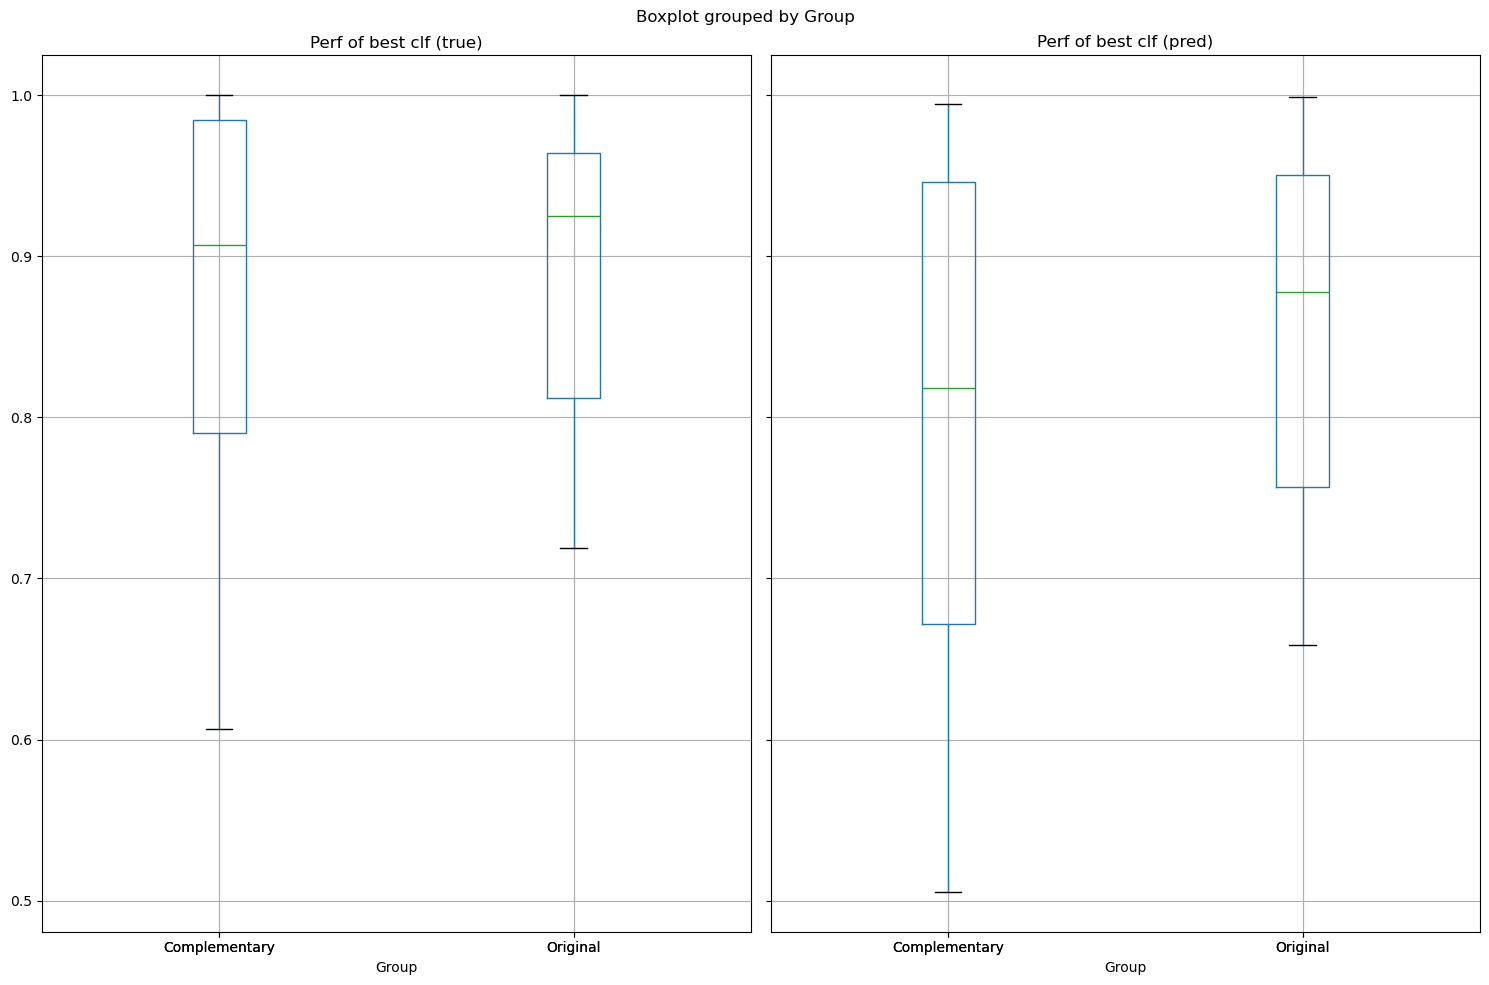

In [41]:
# Visualização final comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Performance por grupo
summary_df.boxplot(column=['Perf of best clf (true)', 'Perf of best clf (pred)'], 
                   by='Group', ax=axes[0, 0], return_type='axes')
axes[0, 0].set_title('Comparação de Performance por Grupo')
axes[0, 0].set_ylabel('Acurácia')
fig.suptitle('')

# 2. Distribuição de melhores classificadores por grupo
best_clf_counts = summary_df.groupby(['Group', 'Best clf (true)']).size().unstack(fill_value=0)
best_clf_counts.plot(kind='bar', ax=axes[0, 1], rot=0)
axes[0, 1].set_title('Distribuição de Melhores Classificadores por Grupo')
axes[0, 1].set_ylabel('Contagem')
axes[0, 1].set_xlabel('Grupo')
axes[0, 1].legend(title='Classificador', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Diferença entre predito e verdadeiro
summary_df['Diff'] = summary_df['Perf of best clf (pred)'] - summary_df['Perf of best clf (true)']
summary_df.boxplot(column='Diff', by='Group', ax=axes[1, 0], return_type='axes')
axes[1, 0].set_title('Diferença: Predito - Verdadeiro')
axes[1, 0].set_ylabel('Diferença de Acurácia')
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 4. Performance geral final
final_summary.boxplot(ax=axes[1, 1], rot=90)
axes[1, 1].set_title('Performance Geral de Todos os Classificadores')
axes[1, 1].set_ylabel('Acurácia')

plt.tight_layout()
plt.show()

In [42]:
# Comparar performance do meta-modelo por grupo
print("Performance do Meta-Modelo por Grupo:\n")

for group in ['Original', 'Complementary']:
    group_data = summary_df[summary_df['Group'] == group]
    
    print(f"\n{group} datasets (n={len(group_data)}):")
    print(f"  Perf média (melhor clf verdadeiro): {group_data['Perf of best clf (true)'].mean():.4f}")
    print(f"  Perf média (melhor clf predito): {group_data['Perf of best clf (pred)'].mean():.4f}")
    print(f"  Diferença média: {(group_data['Perf of best clf (pred)'].mean() - group_data['Perf of best clf (true)'].mean()):.4f}")
    
    # Calcular acurácia do meta-modelo apenas para este grupo
    y_true_group = group_data['Best clf (true)'].values
    y_pred_group = group_data['Best clf (pred)'].values
    acc_group = accuracy_score(y_true_group, y_pred_group)
    print(f"  Acurácia do meta-modelo: {acc_group:.4f}")

summary_df

Performance do Meta-Modelo por Grupo:


Original datasets (n=22):
  Perf média (melhor clf verdadeiro): 0.8937
  Perf média (melhor clf predito): 0.8573
  Diferença média: -0.0364
  Acurácia do meta-modelo: 0.1364

Complementary datasets (n=12):
  Perf média (melhor clf verdadeiro): 0.8684
  Perf média (melhor clf predito): 0.8005
  Diferença média: -0.0679
  Acurácia do meta-modelo: 0.0833


,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred),Group,Diff
0,adult,LogisticRegression,0.805331,DecisionTree,0.799783,Complementary,-0.005548
1,autoUniv-au1-1000,SVM,0.758000,MLP,0.703000,Original,-0.055000
2,bank-marketing,LogisticRegression,0.883546,DecisionTree,0.836235,Complementary,-0.047312
3,blood-transfusion-service-center,LogisticRegression,0.772707,DecisionTree,0.709852,Original,-0.062855
4,car,DecisionTree,0.991897,MLP,0.987273,Complementary,-0.004624
5,cnae-9,MLP,0.955556,SVM,0.919444,Original,-0.036111
6,credit-g,SVM,0.700000,LogisticRegression,0.682000,Complementary,-0.018000
7,diabetes,LogisticRegression,0.770792,MLP,0.658925,Original,-0.111867
8,gas-drift,KNN,0.981955,DecisionTree,0.972178,Complementary,-0.009777
9,heart-statlog,LogisticRegression,0.840741,MLP,0.792593,Complementary,-0.048148


### Análise do Meta-Modelo por Grupo

In [43]:
# Estatísticas detalhadas da comparação
print("Estatísticas por grupo:")
print("\nOriginal datasets:")
print(performances_df[performances_df['Group'] == 'Original']['acc_mean'].describe())
print("\nComplementary datasets:")
print(performances_df[performances_df['Group'] == 'Complementary']['acc_mean'].describe())

Estatísticas por grupo:

Original datasets:
count    132.000000
mean       0.832316
std        0.114226
min        0.575333
25%        0.735989
50%        0.859633
75%        0.929885
max        1.000000
Name: acc_mean, dtype: float64

Complementary datasets:
count    72.000000
mean      0.765495
std       0.153223
min       0.448724
25%       0.652929
50%       0.753847
75%       0.899650
max       1.000000
Name: acc_mean, dtype: float64


In [47]:
# Comparar performance média por grupo de datasets
performance_by_group = performances_df.groupby(['Group', 'Classifier'])['acc_mean'].mean().unstack()
print("Performance média por grupo:")
performance_by_group

Performance média por grupo:


Classifier,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
Group,,,,,,
Complementary,0.837745,0.773364,0.773764,0.793555,0.633060,0.781482
Original,0.839992,0.835379,0.847999,0.856214,0.759148,0.855165


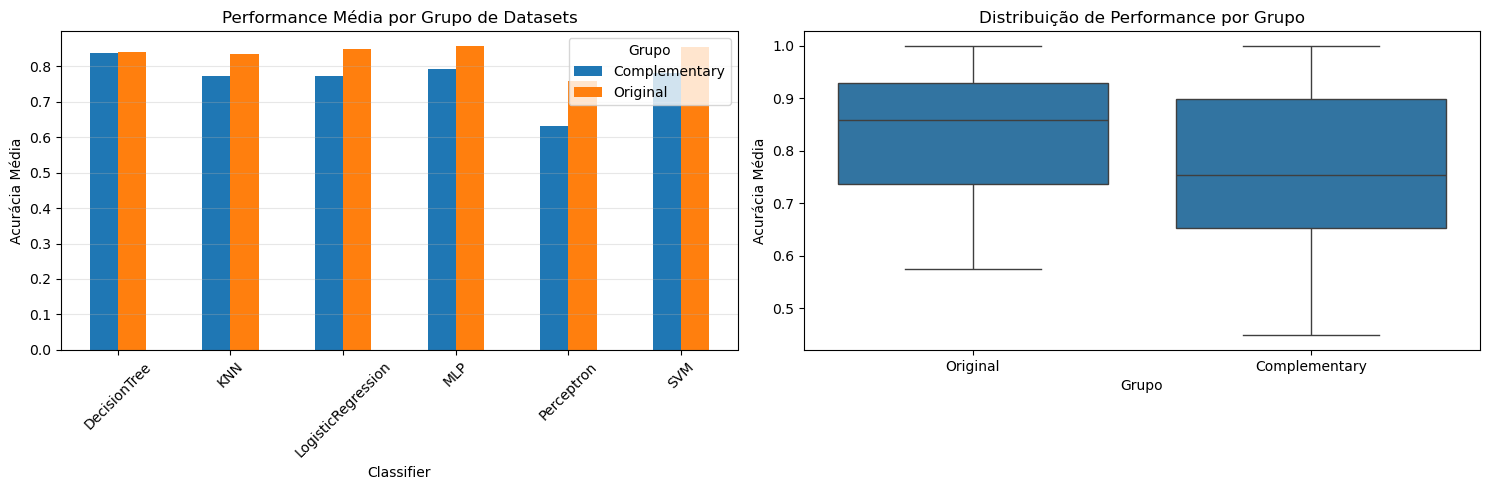

In [49]:
# Visualizar comparação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot performance by group
performance_by_group.T.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Performance Média por Grupo de Datasets')
axes[0].set_ylabel('Acurácia Média')
axes[0].legend(title='Grupo')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot comparison using seaborn to avoid extra figures
sns.boxplot(data=performances_df, x='Group', y='acc_mean', ax=axes[1])
axes[1].set_title('Distribuição de Performance por Grupo')
axes[1].set_ylabel('Acurácia Média')
axes[1].set_xlabel('Grupo')

plt.tight_layout()
plt.show()